# Datasets

This tutorial describes how to access datasets associated with ZAPBench with Python.

Datasets are hosted on Google Cloud Storage in the `zapbench-release` bucket, see [dataset README for acknowledgements and license (CC-BY)](http://zapbench-release.storage.googleapis.com/volumes/README.html). Datasets that may be especially relevant include:

- Functional activity volume (`gs://zapbench-release/volumes/20240930/raw`)
- Functional anatomy volume (`gs://zapbench-release/volumes/20240930/anatomy`)
- Aligned activity volume (`gs://zapbench-release/volumes/20240930/aligned`)
- Aligned and normalized activity volume (`gs://zapbench-release/volumes/20240930/df_over_f`)
- Annotations used for segmentation model training and eval (`gs://zapbench-release/volumes/20240930/annotations/...`)
- Segmentation used to extract traces (`gs://zapbench-release/volumes/20240930/segmentation`)
- Traces used for time-series forecasting (`gs://zapbench-release/volumes/20240930/traces`)

Datasets can also be browsed and downloaded directly using [gsutil](https://cloud.google.com/storage/docs/gsutil), e.g.:

In [ ]:
!gsutil ls gs://zapbench-release/volumes/20240930/

## Loading datasets with TensorStore

We can access these datasets using using [TensorStore](https://google.github.io/tensorstore/). Let's load the raw activity volume, for example:

In [1]:
!pip install tensorstore

E0922 11:16:44.338574 1025987 google_auth_provider.cc:188] Could not find the credentials file in the standard gcloud location [/home/kumarv4@hhmi.org/.config/gcloud/application_default_credentials.json]. You may specify a credentials file using $GOOGLE_APPLICATION_CREDENTIALS, or to use Google application default credentials, run: gcloud auth application-default login


Schema({
  'chunk_layout': {
    'grid_origin': [0, 0, 0, 0],
    'inner_order': [3, 2, 1, 0],
    'read_chunk': {'shape': [512, 512, 1, 1]},
    'write_chunk': {'shape': [512, 512, 1, 1]},
  },
  'codec': {
    'codecs': [
      {'configuration': {'order': [3, 2, 1, 0]}, 'name': 'transpose'},
      {'configuration': {'endian': 'little'}, 'name': 'bytes'},
      {
        'configuration': {
          'blocksize': 0,
          'clevel': 4,
          'cname': 'zstd',
          'shuffle': 'shuffle',
          'typesize': 2,
        },
        'name': 'blosc',
      },
    ],
    'driver': 'zarr3',
  },
  'dimension_units': [
    [406.0, 'nm'],
    [406.0, 'nm'],
    [4000.0, 'nm'],
    [0.9141, 's'],
  ],
  'domain': {
    'exclusive_max': [[2048], [1328], [72], [7879]],
    'inclusive_min': [0, 0, 0, 0],
    'labels': ['x', 'y', 'z', 't'],
  },
  'dtype': 'uint16',
  'fill_value': 0,
  'rank': 4,
})


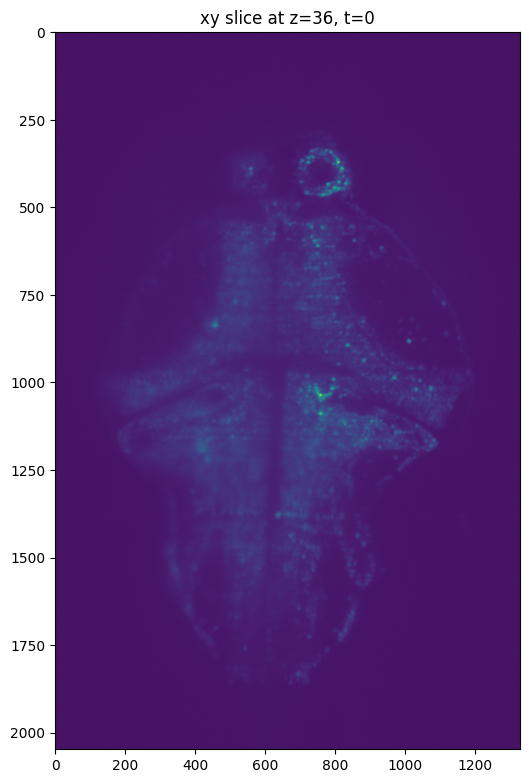

In [3]:
import matplotlib.pyplot as plt
import tensorstore as ts


# Create handle to the remote dataset.
ds = ts.open({
    'open': True,
    # Datasets are generally stored in zarr v3 format ('zarr3').
    # There are a few exceptions, where v2 is used ('zarr').
    'driver': 'zarr3',
    # Path of the dataset we want to load.
    'kvstore': 'gs://zapbench-release/volumes/20240930/raw'
}).result()

# Display info about the dataset.
print(ds.schema)

# Fetch a xy-slice using the handle.
z, t = 36, 0
example_xy_slice = ds[:, :, z, t].read().result()

# Plot slice.
plt.figure(figsize=(6, 12))
plt.imshow(example_xy_slice)
plt.title(f'xy slice at {z=}, {t=}');

## Subsetting the trace matrix

Let's have a look at the trace matrix:

In [4]:
# Create handle to the remote dataset.
ds_traces = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': 'gs://zapbench-release/volumes/20240930/traces'
}).result()

ds_traces.schema

Schema({
  'chunk_layout': {
    'grid_origin': [0, 0],
    'inner_order': [0, 1],
    'read_chunk': {'shape': [512, 512]},
    'write_chunk': {'shape': [512, 512]},
  },
  'codec': {
    'codecs': [{'configuration': {'endian': 'little'}, 'name': 'bytes'}],
    'driver': 'zarr3',
  },
  'domain': {'exclusive_max': [[7879], [71721]], 'inclusive_min': [0, 0]},
  'dtype': 'float32',
  'fill_value': 0.0,
  'rank': 2,
})

As described in [the manuscript](https://openreview.net/pdf?id=oCHsDpyawq), the experiment is subdivided into multiple conditions. Using `zapbench.data_utils` we can get the per-condition bounds for indexing the trace matrix:

In [ ]:
!pip install git+https://github.com/google-research/zapbench.git#egg=zapbench

In [5]:
from zapbench import constants
from zapbench import data_utils

# Print the indexing bounds per condition.
# Note that we keep a minimal amount of "padding" between conditions.
for condition_id, condition_name in enumerate(constants.CONDITION_NAMES):
  inclusive_min, exclusive_max = data_utils.get_condition_bounds(condition_id)
  print(f'{condition_name} has bounds [{inclusive_min}, {exclusive_max}).')

gain has bounds [1, 648).
dots has bounds [650, 2421).
flash has bounds [2423, 3077).
taxis has bounds [3079, 3734).
turning has bounds [3736, 5046).
position has bounds [5048, 5637).
open loop has bounds [5639, 6622).
rotation has bounds [6624, 7278).
dark has bounds [7280, 7878).


Using these bounds, we can get traces for any given condition, e.g.:

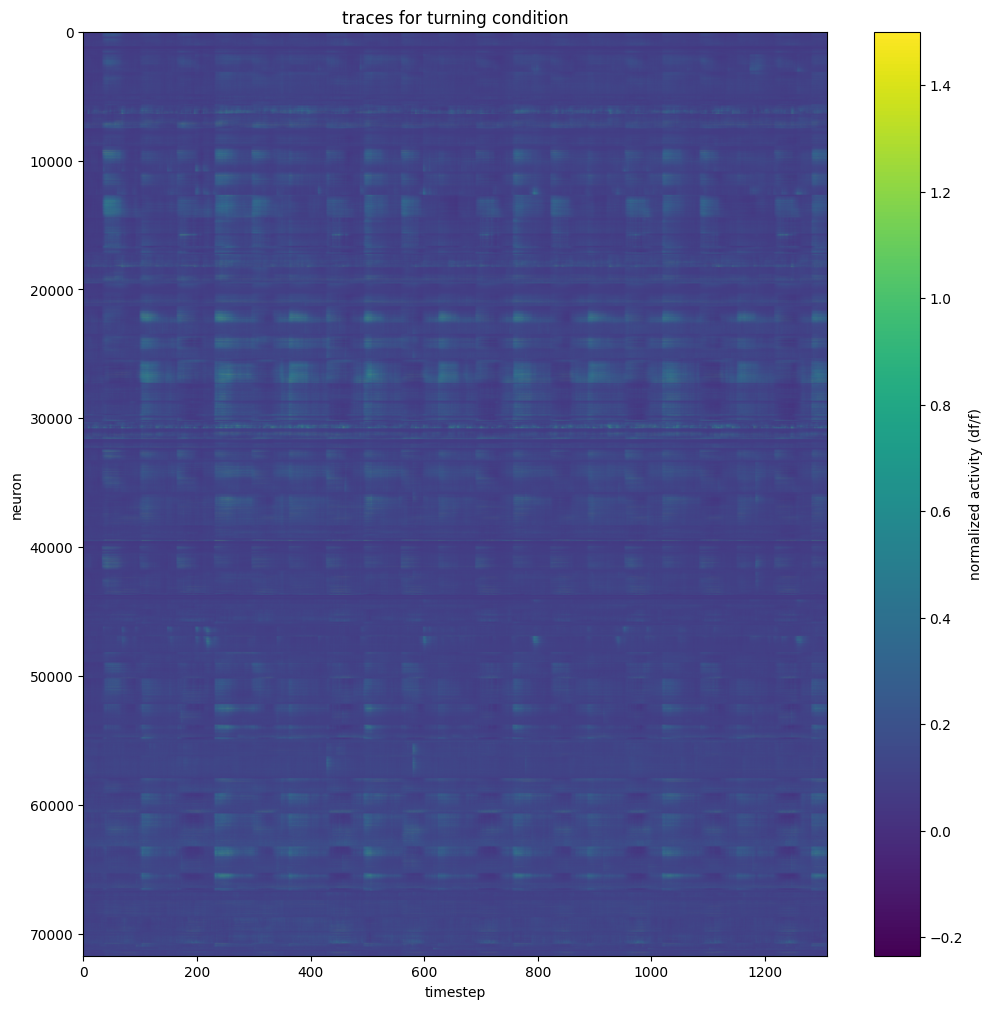

In [6]:
condition_name = 'turning'

# Use the bounds to plot the traces of one of the conditions.
inclusive_min, exclusive_max = data_utils.get_condition_bounds(
    constants.CONDITION_NAMES.index(condition_name))
traces_condition = ds_traces[inclusive_min:exclusive_max, :].read().result()

# Plot traces.
fig = plt.figure(figsize=(12, 12))
plt.title(f'traces for {condition_name} condition')
im = plt.imshow(traces_condition.T, aspect="auto")
plt.xlabel('timestep')
plt.ylabel('neuron')
cbar = fig.colorbar(im)
cbar.set_label("normalized activity (df/f)")
plt.show();

# For training and testing, we will want to further adjust these bounds for
# splits, see `help(data_utils.adjust_condition_bounds_for_split)`.
# As this is covered in other notebooks, we will not do this here.

Note that above plotting interpolates heavily, due to the constrained screen-size. Alternatively, we can use [neuroglancer](https://github.com/google/neuroglancer) to visualize datasets, e.g.:

In [7]:
!pip install neuroglancer

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 56.8 MB/s  0:00:00
  DEPRECATION: Building 'atomicwrites' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'atomicwrites'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for atomicwrites: filename=atomicwrites-1.4.1-py2.py3-none-any.whl size=7020 sha256=f6d688aec2cc22269f19b5677ed411f57c8eb7f0b847d55a9e13d427db64911c
  Stored in directory: /home/kumarv4@hhmi.org/.cache/pip/wheels/17/5c/07/1cbbde9c113ebe939ffd48f9cf7f16e8f170f816792508d044
Successfully built atomicwrites
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [neuroglancer] [neuroglancer]ls]


In [10]:
import neuroglancer as ng
ng.set_server_bind_address(bind_address='127.0.0.1', bind_port=8081)
dimensions = ng.CoordinateSpace(
   names=['time', 'neurons',],
   units='',
   scales=[1, 1, 1],
)
viewer = ng.Viewer()
with viewer.txn() as s:
  s.dimensions = dimensions
  s.layers['raw'] = ng.ImageLayer(
      source=ng.LocalVolume(traces_condition, dimensions))
  s.layout = 'xy'
viewer

http://127.0.0.1:44045/v/c11cb066b71d4aba7e9e77603683684c09035172/